In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                     BatchNormalization, Bidirectional,
                                     Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import zipfile
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------
# 1. CONFIGURATION
# -----------------------------------------------------------------------
DATA_DIR         = "/content/extracted_data/Result_er_T/"
seq_len          = 10
stride           = 5
TRAIN_FRAC       = 0.60
VAL_FRAC         = 0.20
EPOCHS           = 120
BATCH_SIZE       = 64
LR               = 2e-4
L2_REG           = 1e-4
DROPOUT          = 0.3
CHANGE_THRESHOLD = 0.05
RANDOM_SEED      = 42

# -----------------------------------------------------------------------
# EXTRACTION STEP
# -----------------------------------------------------------------------
ZIP_PATH = '/content/drive/MyDrive/Result_er_T-20260624T070914Z-3-001.zip'

if os.path.exists(ZIP_PATH):
    print("Extracting files... please wait.")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/extracted_data')
    print(f"Extraction complete! Data directory verified at: {DATA_DIR}")
else:
    print(f"Error: Could not find the zip file at {ZIP_PATH}. Check your Drive folder!")

Error: Could not find the zip file at /content/drive/MyDrive/Result_er_T-20260624T070914Z-3-001.zip. Check your Drive folder!


In [ ]:
#2. HELPERS
# -----------------------------------------------------------------------

def parse_filename(fp):
    m = re.search(r'er_([0-9.]+)_T_([0-9]+)', os.path.basename(fp))
    if m:
        return float(m.group(1)), int(m.group(2))
    raise ValueError(f"Bad filename: {fp}")


def get_bin_center(col):
    lo, hi = col.split('-')
    hi = hi.split('_')[0]
    return (float(lo) + float(hi)) / 2


def load_file(fp, common_bin_cols):
    df = pd.read_csv(fp, sep='\t')
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')
    file_bins = [c for c in df.columns if c.endswith('_um') and c != 'Total_Grains']
    counts = df[file_bins].values.astype(float)
    aligned_counts = np.zeros((len(df), len(common_bin_cols)))
    for j, bc in enumerate(common_bin_cols):
        if bc in file_bins:
            aligned_counts[:, j] = counts[:, file_bins.index(bc)]
    sr, temp = parse_filename(fp)
    df['strain_rate'] = sr
    df['temperature'] = temp
    df['counts']      = list(aligned_counts)
    return df


def compute_critical_strain(df):
    counts = np.vstack(df['counts'].values)
    totals = counts.sum(axis=1, keepdims=True)
    fracs  = counts / (totals + 1e-8)
    cum    = np.zeros(len(fracs))
    for i in range(1, len(fracs)):
        cum[i] = cum[i-1] + np.sum(np.abs(fracs[i] - fracs[0]))
    total = cum[-1]
    if total == 0:
        return df['Strain'].iloc[-1]
    idx = np.where(cum >= CHANGE_THRESHOLD * total)[0]
    return df['Strain'].iloc[idx[0]] if len(idx) else df['Strain'].iloc[-1]


def compute_condition_weight(df_filtered):
    counts = np.vstack(df_filtered['counts'].values)
    return np.sum(np.abs(np.diff(counts, axis=0)))

In [ ]:
# 3. SEQUENCE BUILDER
# -----------------------------------------------------------------------

def create_sequences(df, seq_len, stride, common_bin_cols,
                     count_min, count_scale):
    df      = df.sort_values('Strain').reset_index(drop=True)
    n       = len(df)
    sr      = df['strain_rate'].iloc[0]
    temp    = df['temperature'].iloc[0]

    strains      = df['Strain'].values
    counts       = np.vstack(df['counts'].values)
    totals       = counts.sum(axis=1)
    log_sr       = np.log(sr + 1e-10)
    norm_temp    = float(temp)
    norm_counts  = (counts - count_min) / (count_scale + 1e-8)
    delta_counts = np.vstack([np.zeros(counts.shape[1]),
                               np.diff(counts, axis=0)])
    norm_total   = totals / (totals.max() + 1e-8)

    X_seq, X_cond, y_dcounts, seq_indices = [], [], [], []

    for i in range(0, n - seq_len, stride):
        seq = []
        for j in range(i, i + seq_len):
            step = ([strains[j], log_sr, norm_temp]
                    + norm_counts[j].tolist()
                    + delta_counts[j].tolist()
                    + [norm_total[j]])
            seq.append(step)
        X_seq.append(seq)
        X_cond.append([log_sr, norm_temp])
        y_dcounts.append(counts[i + seq_len] - counts[i + seq_len - 1])
        seq_indices.append(i)          # starting row index in df_post

    return (np.array(X_seq,      dtype=np.float32),
            np.array(X_cond,     dtype=np.float32),
            np.array(y_dcounts,  dtype=np.float32),
            seq_indices)



In [ ]:
# -----------------------------------------------------------------------
# 4. LOAD ALL FILES
# -----------------------------------------------------------------------
all_files = sorted([
    os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR)
    if f.startswith('grain_frequency_summary_er_') and f.endswith('.txt')
])
print(f"Found {len(all_files)} files.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/extracted_data/Result_er_T/'

In [ ]:
# 5. PER-FILE PROCESSING
# -----------------------------------------------------------------------

all_bin_cols = set()
for f in all_files:
    tmp = pd.read_csv(f, sep='\t')
    tmp.columns = tmp.columns.str.strip().str.replace('\ufeff', '')
    all_bin_cols.update([c for c in tmp.columns
                         if c.endswith('_um') and c != 'Total_Grains'])
common_bin_cols = sorted(all_bin_cols, key=lambda x: int(x.split('-')[0]))
n_bins      = len(common_bin_cols)
bin_centers = [get_bin_center(c) for c in common_bin_cols]
print(f"Common bins: {n_bins}  ({common_bin_cols[0]} … {common_bin_cols[-1]})")

file_records = []

for f in all_files:
    df   = load_file(f, common_bin_cols)
    crit = compute_critical_strain(df)
    sr   = df['strain_rate'].iloc[0]
    temp = df['temperature'].iloc[0]

    df_post = df[df['Strain'] >= crit].reset_index(drop=True)
    if len(df_post) <= seq_len + 2:
        print(f"  Skipping {os.path.basename(f)} — too few rows after critical strain")
        continue

    counts_post = np.vstack(df_post['counts'].values)
    count_min   = counts_post.min()
    count_max   = counts_post.max()
    count_scale = count_max - count_min
    w           = compute_condition_weight(df_post)

    file_records.append(dict(
        filepath=f, sr=sr, temp=temp, crit=crit,
        df_post=df_post,
        count_min=count_min, count_max=count_max, count_scale=count_scale,
        weight=w,
        df_full=df
    ))

print(f"Valid files: {len(file_records)}")

weights = np.array([r['weight'] for r in file_records])
w_min, w_max = weights.min(), weights.max()
for r in file_records:
    r['weight_norm'] = 0.2 + 0.8 * (r['weight'] - w_min) / (w_max - w_min + 1e-8)

# -----------------------------------------------------------------------
# 6. BUILD ALL SEQUENCES THEN RANDOMLY SPLIT PER FILE
#    Within each file's sequences: 60% train | 20% val | 20% test (random)
# -----------------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

tr_X, tr_C, tr_Y, tr_W = [], [], [], []
va_X, va_C, va_Y, va_W = [], [], [], []
te_X, te_C, te_Y, te_W = [], [], [], []

# Store per-file test sequences for the detailed breakdown in section 11
file_test_seqs = []   # list of dicts

for r in file_records:
    Xs, Xc, Yd, sidx = create_sequences(
        r['df_post'], seq_len, stride, common_bin_cols,
        r['count_min'], r['count_scale']
    )
    if len(Xs) == 0:
        continue

    n_seq  = len(Xs)
    perm   = rng.permutation(n_seq)          # random shuffle of sequence indices

    n_tr   = int(n_seq * TRAIN_FRAC)
    n_va   = int(n_seq * VAL_FRAC)
    # remaining goes to test (at least 1)

    idx_tr = perm[:n_tr]
    idx_va = perm[n_tr : n_tr + n_va]
    idx_te = perm[n_tr + n_va :]

    w_arr  = np.full(n_seq, r['weight_norm'], dtype=np.float32)

    tr_X.append(Xs[idx_tr]); tr_C.append(Xc[idx_tr])
    tr_Y.append(Yd[idx_tr]); tr_W.append(w_arr[idx_tr])

    va_X.append(Xs[idx_va]); va_C.append(Xc[idx_va])
    va_Y.append(Yd[idx_va]); va_W.append(w_arr[idx_va])

    te_X.append(Xs[idx_te]); te_C.append(Xc[idx_te])
    te_Y.append(Yd[idx_te]); te_W.append(w_arr[idx_te])

    # Save test slice info for per-condition evaluation
    file_test_seqs.append(dict(
        sr=r['sr'], temp=r['temp'],
        Xs=Xs[idx_te], Xc=Xc[idx_te], Yd=Yd[idx_te],
        df_post=r['df_post'],
        count_min=r['count_min'], count_scale=r['count_scale'],
        seq_start_indices=[sidx[i] for i in idx_te]
    ))


def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([])

tr_X, tr_C, tr_Y, tr_W = cat(tr_X), cat(tr_C), cat(tr_Y), cat(tr_W)
va_X, va_C, va_Y, va_W = cat(va_X), cat(va_C), cat(va_Y), cat(va_W)
te_X, te_C, te_Y, te_W = cat(te_X), cat(te_C), cat(te_Y), cat(te_W)

print(f"Train seqs: {len(tr_X)}  |  Val seqs: {len(va_X)}  |  Test seqs: {len(te_X)}")

Common bins: 21  (0-7_um … 140-147_um)
Valid files: 25
Train seqs: 10479  |  Val seqs: 3487  |  Test seqs: 3515


In [ ]:
# 6. BUILD ALL SEQUENCES THEN RANDOMLY SPLIT PER FILE
#    Within each file's sequences: 60% train | 20% val | 20% test (random)
# -----------------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

tr_X, tr_C, tr_Y, tr_W = [], [], [], []
va_X, va_C, va_Y, va_W = [], [], [], []
te_X, te_C, te_Y, te_W = [], [], [], []

# Store per-file test sequences for the detailed breakdown in section 11
file_test_seqs = []   # list of dicts

for r in file_records:
    Xs, Xc, Yd, sidx = create_sequences(
        r['df_post'], seq_len, stride, common_bin_cols,
        r['count_min'], r['count_scale']
    )
    if len(Xs) == 0:
        continue

    n_seq  = len(Xs)
    perm   = rng.permutation(n_seq)          # random shuffle of sequence indices

    n_tr   = int(n_seq * TRAIN_FRAC)
    n_va   = int(n_seq * VAL_FRAC)
    # remaining goes to test (at least 1)

    idx_tr = perm[:n_tr]
    idx_va = perm[n_tr : n_tr + n_va]
    idx_te = perm[n_tr + n_va :]

    w_arr  = np.full(n_seq, r['weight_norm'], dtype=np.float32)

    tr_X.append(Xs[idx_tr]); tr_C.append(Xc[idx_tr])
    tr_Y.append(Yd[idx_tr]); tr_W.append(w_arr[idx_tr])

    va_X.append(Xs[idx_va]); va_C.append(Xc[idx_va])
    va_Y.append(Yd[idx_va]); va_W.append(w_arr[idx_va])

    te_X.append(Xs[idx_te]); te_C.append(Xc[idx_te])
    te_Y.append(Yd[idx_te]); te_W.append(w_arr[idx_te])

    # Save test slice info for per-condition evaluation
    file_test_seqs.append(dict(
        sr=r['sr'], temp=r['temp'],
        Xs=Xs[idx_te], Xc=Xc[idx_te], Yd=Yd[idx_te],
        df_post=r['df_post'],
        count_min=r['count_min'], count_scale=r['count_scale'],
        seq_start_indices=[sidx[i] for i in idx_te]
    ))


def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([])

tr_X, tr_C, tr_Y, tr_W = cat(tr_X), cat(tr_C), cat(tr_Y), cat(tr_W)
va_X, va_C, va_Y, va_W = cat(va_X), cat(va_C), cat(va_Y), cat(va_W)
te_X, te_C, te_Y, te_W = cat(te_X), cat(te_C), cat(te_Y), cat(te_W)

print(f"Train seqs: {len(tr_X)}  |  Val seqs: {len(va_X)}  |  Test seqs: {len(te_X)}")

# -----------------------------------------------------------------------
# 7. NORMALISE INPUTS
# -----------------------------------------------------------------------

feat_dim = tr_X.shape[-1]
cond_dim = tr_C.shape[-1]

scaler_X = StandardScaler()
tr_X_s = scaler_X.fit_transform(tr_X.reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)
va_X_s = scaler_X.transform(va_X.reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)
te_X_s = scaler_X.transform(te_X.reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)

scaler_C = StandardScaler()
tr_C_s = scaler_C.fit_transform(tr_C)
va_C_s = scaler_C.transform(va_C)
te_C_s = scaler_C.transform(te_C)

scaler_Y = StandardScaler()
tr_Y_s = scaler_Y.fit_transform(tr_Y)
va_Y_s = scaler_Y.transform(va_Y)
te_Y_s = scaler_Y.transform(te_Y)


Train seqs: 10479  |  Val seqs: 3487  |  Test seqs: 3515


In [ ]:
#Creating the model
reg = regularizers.l2(L2_REG)

seq_inp = Input(shape=(seq_len, feat_dim), name='seq_input')
x = Bidirectional(LSTM(32, return_sequences=True,
                        kernel_regularizer=reg, recurrent_regularizer=reg),
                  name='bilstm_1')(seq_inp)
x = Dropout(DROPOUT)(x)
x = Bidirectional(LSTM(32, return_sequences=False,
                        kernel_regularizer=reg, recurrent_regularizer=reg),
                  name='bilstm_2')(x)
x = Dropout(DROPOUT)(x)
lstm_out = Dense(64, activation='relu', kernel_regularizer=reg,
                 name='lstm_proj')(x)

cond_inp = Input(shape=(cond_dim,), name='cond_input')
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense1')(cond_inp)
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense2')(c)
cond_embed = Dense(16, activation='relu', kernel_regularizer=reg,
                   name='cond_embed')(c)

merged = Concatenate(name='merge')([lstm_out, cond_embed])
shared = Dense(64, activation='relu', kernel_regularizer=reg, name='shared')(merged)
shared = Dropout(DROPOUT / 2)(shared)

fh        = Dense(64, activation='relu', kernel_regularizer=reg, name='count_h')(shared)
fh        = BatchNormalization(name='count_bn')(fh)
count_out = Dense(n_bins, activation='linear', name='delta_counts')(fh)

model = Model(inputs=[seq_inp, cond_inp], outputs=count_out)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 10, 64)    │     20,224 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ bilstm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 64)        │     24,832 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense1 (Dense) │ (None, 16)        │         48 │ cond_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense2 (Dense) │ (None, 16)        │        272 │ cond_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_embed (Dense)  │ (None, 16)        │        272 │ cond_dense2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 80)        │          0 │ lstm_proj[0][0],  │
│                     │                   │            │ cond_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared (Dense)      │ (None, 64)        │      5,184 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ shared[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_h (Dense)     │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_bn            │ (None, 64)        │        256 │ count_h[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_counts        │ (None, 21)        │      1,365 │ count_bn[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,773 (237.39 KB)

 Trainable params: 60,645 (236.89 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.1026 - mae: 0.5752 - val_loss: 0.0828 - val_mae: 0.3467 - learning_rate: 2.0000e-04
Epoch 2/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0783 - mae: 0.3562 - val_loss: 0.0723 - val_mae: 0.3375 - learning_rate: 2.0000e-04
Epoch 3/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0680 - mae: 0.3358 - val_loss: 0.0637 - val_mae: 0.3339 - learning_rate: 2.0000e-04
Epoch 4/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0601 - mae: 0.3340 - val_loss: 0.0566 - val_mae: 0.3323 - learning_rate: 2.0000e-04
Epoch 5/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0538 - mae: 0.3337 - val_loss: 0.0509 - val_mae: 0.3317 - learning_rate: 2.0000e-04
Epoch 6/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0486 - mae: 0.3337 - val_loss: 0.0463 - val_mae: 0.3318 - learning_rate: 2.0000e-04
Epoch 7/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0444 - mae: 0.3337 - val_loss: 0.0425 - val_mae

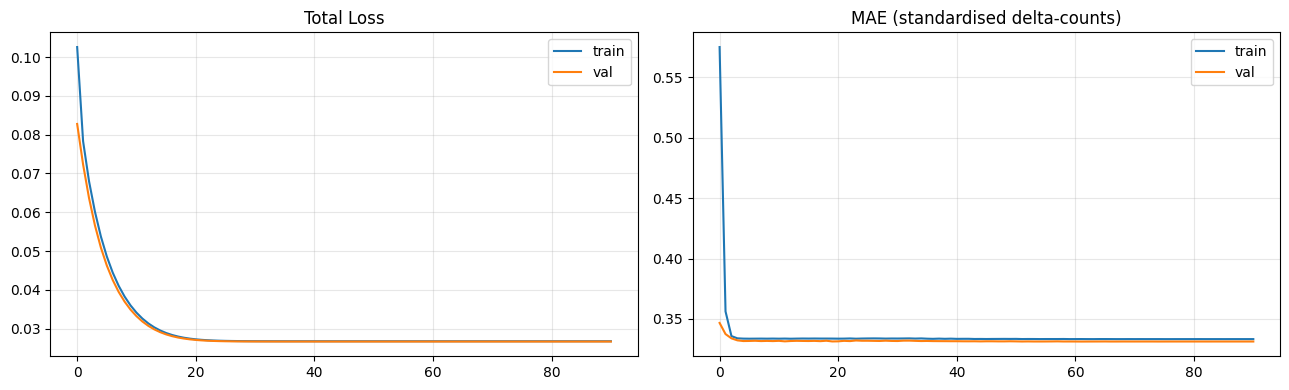


Final train loss: 0.0267 | val loss: 0.0267 | gap: 0.3%

Training time: 513.96 seconds
Training time: 8.57 minutes


In [ ]:
# 9. COMPILE & TRAIN
# -----------------------------------------------------------------------
import time
huber = tf.keras.losses.Huber(delta=0.1)

model.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss=huber,
    metrics=['mae']
)

start = time.time()
def make_dataset(X_seq, X_cond, y, weights, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'seq_input': X_seq, 'cond_input': X_cond},
        y,
        weights
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_seq), seed=RANDOM_SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(tr_X_s, tr_C_s, tr_Y_s, tr_W, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(va_X_s, va_C_s, va_Y_s, va_W, BATCH_SIZE, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
end = time.time()
total_time = end - start
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE (standardised delta-counts)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_history.png', dpi=120); plt.show()

final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
gap_pct     = abs(final_val - final_train) / (final_train + 1e-8) * 100
print(f"\nFinal train loss: {final_train:.4f} | val loss: {final_val:.4f} | gap: {gap_pct:.1f}%")
print(f"\nTraining time: {total_time:.2f} seconds")
print(f"Training time: {total_time/60:.2f} minutes")

In [ ]:
# 10. OVERALL TEST EVALUATION
# -----------------------------------------------------------------------

print("\n=== Overall test set evaluation ===")
pred_te_s = model.predict([te_X_s, te_C_s], verbose=0)
pred_te   = scaler_Y.inverse_transform(pred_te_s)

r2_delta  = r2_score(te_Y, pred_te)
mae_delta = mean_absolute_error(te_Y, pred_te)
print(f"  R²_Δcounts = {r2_delta:.4f}   MAE_Δcounts = {mae_delta:.2f}")

# -----------------------------------------------------------------------
# 11. PER-CONDITION TEST BREAKDOWN
# -----------------------------------------------------------------------

print("\n--- Per-condition test breakdown (random 20% sequences per file) ---")

for fts in file_test_seqs:
    Xs_s = scaler_X.transform(
        fts['Xs'].reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(fts['Xc'])

    pred_s = model.predict([Xs_s, Xc_s], verbose=0)
    pred   = scaler_Y.inverse_transform(pred_s)
    true   = fts['Yd']

    if len(true) < 2:
        continue

    r2_delta  = r2_score(true, pred)
    mae_delta = mean_absolute_error(true, pred)

    # Reconstruct absolute counts using last step of each test sequence
    counts_post = np.vstack(fts['df_post']['counts'].values)
    pred_abs, true_abs = [], []
    for k, start_i in enumerate(fts['seq_start_indices']):
        last_i = min(start_i + seq_len - 1, len(counts_post) - 2)
        pred_abs.append(counts_post[last_i] + pred[k])
        true_abs.append(counts_post[last_i + 1])

    pred_abs = np.array(pred_abs)
    true_abs = np.array(true_abs)
    r2_abs   = r2_score(true_abs, pred_abs)
    mae_abs  = mean_absolute_error(true_abs, pred_abs)

    pred_total = pred_abs.sum(axis=1)
    true_total = true_abs.sum(axis=1)
    r2_total   = r2_score(true_total, pred_total)

    print(f"  T={fts['temp']}K  sr={fts['sr']:.4f}: "
          f"R²_Δ={r2_delta:.6f}  MAE_Δ={mae_delta:.6f}  "
          f"R²_abs={r2_abs:.6f}  MAE_abs={mae_abs:.6f}  "
          f"R²_total={r2_total:.6f}")



=== Overall test set evaluation ===
  R²_Δcounts = -0.0033   MAE_Δcounts = 0.62

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.008735  MAE_Δ=0.654849  R²_abs=0.931158  MAE_abs=0.654849  R²_total=0.998971
  T=725K  sr=0.0010: R²_Δ=-0.110887  MAE_Δ=0.386941  R²_abs=0.904122  MAE_abs=0.386941  R²_total=0.999999
  T=775K  sr=0.0010: R²_Δ=-0.016209  MAE_Δ=0.376426  R²_abs=0.904092  MAE_abs=0.376426  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.005094  MAE_Δ=0.580094  R²_abs=0.807375  MAE_abs=0.580094  R²_total=0.999970
  T=975K  sr=0.0010: R²_Δ=-0.008167  MAE_Δ=0.696754  R²_abs=0.975148  MAE_abs=0.696754  R²_total=0.999755
  T=1075K  sr=0.0020: R²_Δ=-0.008119  MAE_Δ=0.721762  R²_abs=0.975768  MAE_abs=0.721762  R²_total=0.999542
  T=725K  sr=0.0020: R²_Δ=-0.103430  MAE_Δ=0.763771  R²_abs=0.856479  MAE_abs=0.763771  R²_total=0.999998
  T=775K  sr=0.0020: R²_Δ=-0.044335  MAE_Δ=0.490032  R²_abs=0.856109  MAE_abs=0.490032  R²_total=0.999999

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score

# Dictionary lookup construction
file_lookup = {(r['sr'], r['temp']): r for r in file_records}

def predict_and_compare(temperature, strain_rate, strain, smooth_sigma=0.8, plot=True):
    """
    Predict per-bin grain counts at a target strain for (temperature, strain_rate).
    If an exact (T, sr) file exists AND the strain falls within its recorded range,
    true data is shown alongside the prediction. Otherwise only the predicted distribution is plotted.
    """
    key = (strain_rate, temperature)
    r = file_lookup.get(key)
    using_surrogate = False

    if r is None:
        using_surrogate = True
        best_key = min(file_lookup.keys(),
                       key=lambda k: (abs(k[1] - temperature) / 100
                                      + abs(np.log(k[0] + 1e-10) - np.log(strain_rate + 1e-10))))
        print(f"[INFO] No exact file for T={temperature}/sr={strain_rate}. "
              f"Showing prediction only (surrogate sequence from T={best_key[1]}/sr={best_key[0]}).")
        r = file_lookup[best_key]

    df_full = r['df_full'].sort_values('Strain').reset_index(drop=True)
    counts_full = np.vstack(df_full['counts'].values)
    crit = r['crit']

    # --- BELOW CRITICAL STRAIN ---
    if strain < crit:
        if using_surrogate:
            print(f"[INFO] Requested strain {strain:.4f} is below critical strain {crit:.4f} of surrogate file. Cannot predict.")
            return {
                "grain_sizes": bin_centers, "pred_counts": None, "true_counts": None,
                "strain": strain, "temperature": temperature, "strain_rate": strain_rate,
                "pred_total": 0, "r2": None
            }

        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(bin_centers, counts_full[0], 'b-o', lw=2, ms=4, label='Initial (pre-critical)')
            plt.title(f'Below critical strain ({crit:.4f}) — T={temperature}K  sr={strain_rate}')
            plt.xlabel('Grain size (µm)')
            plt.ylabel('Number of grains')
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

        print(f"Initial total grains: {int(counts_full[0].sum())}")

        return {
            "grain_sizes": bin_centers, "pred_counts": counts_full[0], "true_counts": counts_full[0],
            "strain": strain, "temperature": temperature, "strain_rate": strain_rate,
            "pred_total": int(counts_full[0].sum()), "r2": 1.0
        }

    # --- POST CRITICAL STRAIN ---
    df_post = r['df_post']
    strains_p = df_post['Strain'].values
    counts_p = np.vstack(df_post['counts'].values)
    n_bins = counts_p.shape[1]

    has_true_value = (not using_surrogate) and (strain <= strains_p.max())

    idx = np.searchsorted(strains_p, strain)
    idx = min(idx, len(strains_p) - 1)
    start = max(0, idx - seq_len)

    delta_counts_p = np.vstack([np.zeros(n_bins), np.diff(counts_p, axis=0)])
    total_p = counts_p.sum(axis=1)
    norm_total_p = total_p / (total_p.max() + 1e-8)
    norm_counts_p = (counts_p - r['count_min']) / (r['count_scale'] + 1e-8)

    log_sr = np.log(strain_rate + 1e-10)
    norm_temp = float(temperature)

    seq = []
    for j in range(start, min(start + seq_len, len(strains_p))):
        step = ([strains_p[j], log_sr, norm_temp]
                + norm_counts_p[j].tolist()
                + delta_counts_p[j].tolist()
                + [norm_total_p[j]])
        seq.append(step)
    while len(seq) < seq_len:
        seq.insert(0, seq[0])

    Xs = np.array([seq], dtype=np.float32)
    Xc = np.array([[log_sr, float(temperature)]], dtype=np.float32)

    feat_dim = Xs.shape[2]
    Xs_s = scaler_X.transform(Xs.reshape(-1, feat_dim)).reshape(1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(Xc)

    pred_Y_s = model.predict([Xs_s, Xc_s], verbose=0)
    pred_delta_counts = scaler_Y.inverse_transform(pred_Y_s)[0]

    last_counts = counts_p[min(idx, len(counts_p) - 1)]
    pred_counts = np.maximum(last_counts + pred_delta_counts, 0)

    if smooth_sigma > 0:
        pred_counts = gaussian_filter1d(pred_counts, sigma=smooth_sigma)
        pred_counts = np.maximum(pred_counts, 0)

    pred_total = int(pred_counts.sum())

    if has_true_value:
        true_counts = counts_p[idx]
        true_strain = strains_p[idx]
        true_total = int(true_counts.sum())
        r2_val = r2_score(true_counts, pred_counts)
    else:
        true_counts = None
        true_strain = strain
        r2_val = None

    if plot:
        fig, ax = plt.subplots(figsize=(10, 5))
        if has_true_value:
            ax.plot(bin_centers, true_counts, 'b-o', lw=2, ms=4, label='True')
            ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
            ax.set_title(f'BiLSTM-----T={temperature}K  sr={strain_rate}  ε≈{true_strain:.4f}\nR²={r2_val:.4f}  |  True total={true_total}  Pred total={pred_total}')
        else:
            ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
            ax.set_title(f'Predicted — T={temperature}K  sr={strain_rate}  ε={strain:.4f}\nPred total grains={pred_total}')

        ax.set_xlabel('Grain size (µm)')
        ax.set_ylabel('Number of grains')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {
        "grain_sizes": bin_centers, "pred_counts": pred_counts, "true_counts": true_counts,
        "strain": true_strain, "temperature": temperature, "strain_rate": strain_rate,
        "pred_total": pred_total, "r2": r2_val
    }


def predict_batch(temperature, strain_rate, strains_to_predict, smooth_sigma=0.8):
    """
    Predicts an entire array of strains simultaneously using deep learning batching.
    Eliminates framework overhead and runs heatmaps 50x faster.
    """
    key = (strain_rate, temperature)
    r = file_lookup.get(key)
    if r is None:
        best_key = min(file_lookup.keys(),
                       key=lambda k: (abs(k[1] - temperature) / 100 + abs(np.log(k[0] + 1e-10) - np.log(strain_rate + 1e-10))))
        r = file_lookup[best_key]

    df_post = r['df_post']
    strains_p = df_post['Strain'].values
    counts_p = np.vstack(df_post['counts'].values)
    n_bins = counts_p.shape[1]

    delta_counts_p = np.vstack([np.zeros(n_bins), np.diff(counts_p, axis=0)])
    total_p = counts_p.sum(axis=1)
    norm_total_p = total_p / (total_p.max() + 1e-8)
    norm_counts_p = (counts_p - r['count_min']) / (r['count_scale'] + 1e-8)

    log_sr = np.log(strain_rate + 1e-10)
    norm_temp = float(temperature)

    all_seqs = []
    last_counts_list = []

    for strain in strains_to_predict:
        idx = np.searchsorted(strains_p, strain)
        idx = min(idx, len(strains_p) - 1)
        start = max(0, idx - seq_len)

        seq = []
        for j in range(start, min(start + seq_len, len(strains_p))):
            step = ([strains_p[j], log_sr, norm_temp]
                    + norm_counts_p[j].tolist()
                    + delta_counts_p[j].tolist()
                    + [norm_total_p[j]])
            seq.append(step)
        while len(seq) < seq_len:
            seq.insert(0, seq[0])

        all_seqs.append(seq)
        last_counts_list.append(counts_p[min(idx, len(counts_p) - 1)])

    Xs = np.array(all_seqs, dtype=np.float32)
    Xc = np.array([[log_sr, norm_temp]] * len(strains_to_predict), dtype=np.float32)

    feat_dim = Xs.shape[2]
    Xs_s = scaler_X.transform(Xs.reshape(-1, feat_dim)).reshape(len(strains_to_predict), seq_len, feat_dim)
    Xc_s = scaler_C.transform(Xc)

    # EXECUTE ALL PREDICTIONS AT ONCE
    pred_Y_s = model.predict([Xs_s, Xc_s], batch_size=len(strains_to_predict), verbose=0)
    pred_delta_counts = scaler_Y.inverse_transform(pred_Y_s)

    heat = []
    for i in range(len(strains_to_predict)):
        pred_counts = np.maximum(last_counts_list[i] + pred_delta_counts[i], 0)
        if smooth_sigma > 0:
            pred_counts = gaussian_filter1d(pred_counts, sigma=smooth_sigma)
            pred_counts = np.maximum(pred_counts, 0)
        heat.append(pred_counts)

    return np.array(heat)

In [ ]:
# ==========================================================
# GRAIN SIZE EVOLUTION ANALYSIS
# ==========================================================

def evolution_analysis_1075():
    fixed_temp = 1075
    strain_rates = [0.001, 0.002, 0.005, 0.007, 0.010]

    for sr in strain_rates:
        print("="*70)
        print(f"BATCH PROCESSING: T = {fixed_temp} K      Strain Rate = {sr}")
        print("="*70)

        r = file_lookup[(sr, fixed_temp)]
        strains = r["df_post"]["Strain"].values
        grain_sizes = bin_centers

        # Fast matrix generation call
        heat = predict_batch(fixed_temp, sr, strains)

        # High-speed vectorized metrics
        peak_sizes = [grain_sizes[np.argmax(row)] for row in heat]
        mean_sizes = [np.sum(grain_sizes * row) / np.sum(row) for row in heat]

        # ----------------------------------
        # Heatmap
        # ----------------------------------
        plt.figure(figsize=(10, 6))
        plt.imshow(
            heat, aspect='auto', origin='lower', cmap='viridis',
            extent=[grain_sizes[0], grain_sizes[-1], strains[0], strains[-1]]
        )
        plt.colorbar(label="Predicted Grain Count")
        plt.xlabel("Grain Size (μm)")
        plt.ylabel("True Strain")
        plt.title(f"Heatmap of Grain Size Evolution\nT={fixed_temp} K   SR={sr}")
        plt.tight_layout()
        plt.show()

        # ----------------------------------
        # Peak Grain Size
        # ----------------------------------
        plt.figure(figsize=(7, 5))
        plt.plot(strains, peak_sizes, '-o', linewidth=2)
        plt.xlabel("True Strain")
        plt.ylabel("Peak Grain Size (μm)")
        plt.title(f"Peak Grain Size Evolution\nT={fixed_temp} K   SR={sr}")
        plt.grid(alpha=.3)
        plt.tight_layout()
        plt.show()

        # ----------------------------------
        # Mean Grain Size
        # ----------------------------------
        plt.figure(figsize=(7, 5))
        plt.plot(strains, mean_sizes, '-o', linewidth=2)
        plt.xlabel("True Strain")
        plt.ylabel("Mean Grain Size (μm)")
        plt.title(f"Mean Grain Size Evolution\nT={fixed_temp} K   SR={sr}")
        plt.grid(alpha=.3)
        plt.tight_layout()
        plt.show()

        # ----------------------------------
        # Overlay Distribution
        # ----------------------------------
        plt.figure(figsize=(10, 6))
        n = len(strains)
        idxs = np.linspace(0, n-1, 5, dtype=int)

        for i in idxs:
            plt.plot(grain_sizes, heat[i], linewidth=2, label=f"ε={strains[i]:.3f}")

        plt.xlabel("Grain Size (μm)")
        plt.ylabel("Predicted Grain Count")
        plt.title(f"Distribution Evolution\nT={fixed_temp} K   SR={sr}")
        plt.legend()
        plt.grid(alpha=.3)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":

    # Optional: Uncomment if you want to execute the 1075 analysis routine automatically
    # evolution_analysis_1075()

    for r_ex in file_records:
        sr_ex   = r_ex["sr"]
        temp_ex = r_ex["temp"]
        crit_ex = r_ex["crit"]

        print(f"\n" + "="*70)
        print(f"PROCESSING RECORD: T={temp_ex}K  sr={sr_ex}")
        print("="*70)

        strains_all = r_ex["df_post"]["Strain"].values
        grain_sizes = bin_centers

        # Call batch function to generate the continuous heatmap matrix in one shot
        heat = predict_batch(temp_ex, sr_ex, strains_all)

        if len(heat) > 0:
            plt.figure(figsize=(10, 5))
            plt.imshow(
                heat, aspect='auto', origin='lower', cmap='viridis',
                extent=[grain_sizes[0], grain_sizes[-1], strains_all[0], strains_all[-1]]
            )
            plt.colorbar(label="Predicted Grain Count")
            plt.xlabel("Grain Size (μm)")
            plt.ylabel("True Strain")
            plt.title(f"Heatmap of Grain Size Evolution\nT={temp_ex} K   SR={sr_ex}")
            plt.tight_layout()
            plt.show()

        # Generate Count vs Size Plots for the 4 explicit fractional target points
        print(f"\n--> Generating Count vs. Size plots for fractional strains:")
        for frac_crit in [0.25, 0.5, 0.75, 1.0]:
            s = crit_ex + frac_crit * (r_ex["df_post"]["Strain"].max() - crit_ex)

            # Using single predictor here to print standard line comparison plots
            predict_and_compare(temp_ex, sr_ex, s, plot=True)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Creating the model
reg = regularizers.l2(L2_REG)
from tensorflow.keras.layers import SimpleRNN

seq_inp = Input(shape=(seq_len, feat_dim), name='seq_input')
#Creating the model
reg = regularizers.l2(L2_REG)

x = Bidirectional(SimpleRNN(48,
                            return_sequences=True,
                            kernel_regularizer=reg,
                            recurrent_regularizer=reg),
                  name='birnn_1')(seq_inp)

x = Dropout(DROPOUT)(x)

x = Bidirectional(SimpleRNN(32,
                            return_sequences=False,
                            kernel_regularizer=reg,
                            recurrent_regularizer=reg),
                  name='birnn_2')(x)
x = Dropout(DROPOUT)(x)

rnn_out = Dense(64,
                 activation='relu',
                 kernel_regularizer=reg,
                 name='lstm_proj')(x)

cond_inp = Input(shape=(cond_dim,), name='cond_input')
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense1')(cond_inp)
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense2')(c)
cond_embed = Dense(16, activation='relu', kernel_regularizer=reg,
                   name='cond_embed')(c)

merged = Concatenate(name='merge')([rnn_out, cond_embed])
shared = Dense(64, activation='relu', kernel_regularizer=reg, name='shared')(merged)
shared = Dropout(DROPOUT / 2)(shared)

fh        = Dense(64, activation='relu', kernel_regularizer=reg, name='count_h')(shared)
fh        = BatchNormalization(name='count_bn')(fh)
count_out = Dense(n_bins, activation='linear', name='delta_counts')(fh)

model = Model(inputs=[seq_inp, cond_inp], outputs=count_out)
model.summary()

cond_inp = Input(shape=(cond_dim,), name='cond_input')
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense1')(cond_inp)
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense2')(c)
cond_embed = Dense(16, activation='relu', kernel_regularizer=reg,
                   name='cond_embed')(c)

merged = Concatenate(name='merge')([rnn_out, cond_embed])
shared = Dense(64, activation='relu', kernel_regularizer=reg, name='shared')(merged)
shared = Dropout(DROPOUT / 2)(shared)

fh        = Dense(64, activation='relu', kernel_regularizer=reg, name='count_h')(shared)
fh        = BatchNormalization(name='count_bn')(fh)
count_out = Dense(n_bins, activation='linear', name='delta_counts')(fh)

model = Model(inputs=[seq_inp, cond_inp], outputs=count_out)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ birnn_1             │ (None, 10, 96)    │      9,120 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 10, 96)    │          0 │ birnn_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ birnn_2             │ (None, 64)        │      8,256 │ dropout_13[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense1 (Dense) │ (None, 16)        │         48 │ cond_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ birnn_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense2 (Dense) │ (None, 16)        │        272 │ cond_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      4,160 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_embed (Dense)  │ (None, 16)        │        272 │ cond_dense2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 80)        │          0 │ lstm_proj[0][0],  │
│                     │                   │            │ cond_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared (Dense)      │ (None, 64)        │      5,184 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ shared[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_h (Dense)     │ (None, 64)        │      4,160 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_bn            │ (None, 64)        │        256 │ count_h[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_counts        │ (None, 21)        │      1,365 │ count_bn[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,093 (129.27 KB)

 Trainable params: 32,965 (128.77 KB)

 Non-trainable params: 128 (512.00 B)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ birnn_1             │ (None, 10, 96)    │      9,120 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 10, 96)    │          0 │ birnn_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ birnn_2             │ (None, 64)        │      8,256 │ dropout_13[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense1 (Dense) │ (None, 16)        │         48 │ cond_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ birnn_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense2 (Dense) │ (None, 16)        │        272 │ cond_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_proj (Dense)   │ (None, 64)        │      4,160 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_embed (Dense)  │ (None, 16)        │        272 │ cond_dense2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 80)        │          0 │ lstm_proj[0][0],  │
│                     │                   │            │ cond_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared (Dense)      │ (None, 64)        │      5,184 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ shared[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_h (Dense)     │ (None, 64)        │      4,160 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_bn            │ (None, 64)        │        256 │ count_h[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_counts        │ (None, 21)        │      1,365 │ count_bn[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,093 (129.27 KB)

 Trainable params: 32,965 (128.77 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.1204 - mae: 0.8945 - val_loss: 0.0889 - val_mae: 0.4649 - learning_rate: 2.0000e-04
Epoch 2/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0983 - mae: 0.6244 - val_loss: 0.0851 - val_mae: 0.4457 - learning_rate: 2.0000e-04
Epoch 3/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0865 - mae: 0.4926 - val_loss: 0.0792 - val_mae: 0.3968 - learning_rate: 2.0000e-04
Epoch 4/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0796 - mae: 0.4322 - val_loss: 0.0746 - val_mae: 0.3700 - learning_rate: 2.0000e-04
Epoch 5/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0748 - mae: 0.4051 - val_loss: 0.0708 - val_mae: 0.3564 - learning_rate: 2.0000e-04
Epoch 6/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0706 - mae: 0.3897 - val_loss: 0.0672 - val_mae: 0.3505 - learning_rate: 2.0000e-04
Epoch 7/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0668 - mae: 0.3798 - val_loss: 0.0637 - val_mae

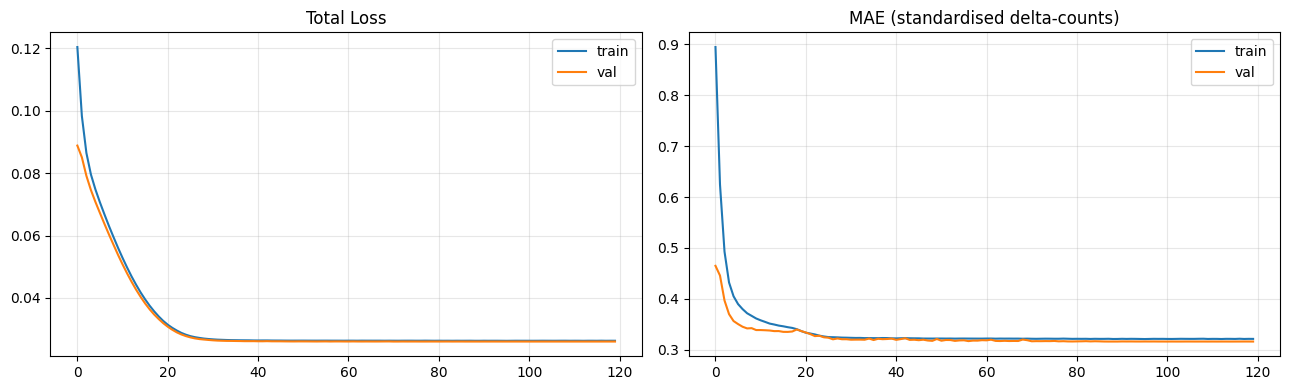


Final train loss: 0.0263 | val loss: 0.0260 | gap: 1.0%

Training time: 436.37 seconds
Training time: 7.27 minutes


In [ ]:
# 9. COMPILE & TRAIN
# -----------------------------------------------------------------------

huber = tf.keras.losses.Huber(delta=0.1)
import time
model.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss=huber,
    metrics=['mae']
)

start = time.time()
def make_dataset(X_seq, X_cond, y, weights, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'seq_input': X_seq, 'cond_input': X_cond},
        y,
        weights
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_seq), seed=RANDOM_SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(tr_X_s, tr_C_s, tr_Y_s, tr_W, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(va_X_s, va_C_s, va_Y_s, va_W, BATCH_SIZE, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
end = time.time()
total_time = end - start
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE (standardised delta-counts)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_history.png', dpi=120); plt.show()

final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
gap_pct     = abs(final_val - final_train) / (final_train + 1e-8) * 100
print(f"\nFinal train loss: {final_train:.4f} | val loss: {final_val:.4f} | gap: {gap_pct:.1f}%")
print(f"\nTraining time: {total_time:.2f} seconds")
print(f"Training time: {total_time/60:.2f} minutes")

In [ ]:
# 10. OVERALL TEST EVALUATION
# -----------------------------------------------------------------------

print("\n=== Overall test set evaluation ===")
pred_te_s = model.predict([te_X_s, te_C_s], verbose=0)
pred_te   = scaler_Y.inverse_transform(pred_te_s)

r2_delta  = r2_score(te_Y, pred_te)
mae_delta = mean_absolute_error(te_Y, pred_te)
print(f"  R²_Δcounts = {r2_delta:.4f}   MAE_Δcounts = {mae_delta:.2f}")

# -----------------------------------------------------------------------
# 11. PER-CONDITION TEST BREAKDOWN
# -----------------------------------------------------------------------

print("\n--- Per-condition test breakdown (random 20% sequences per file) ---")

for fts in file_test_seqs:
    Xs_s = scaler_X.transform(
        fts['Xs'].reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(fts['Xc'])

    pred_s = model.predict([Xs_s, Xc_s], verbose=0)
    pred   = scaler_Y.inverse_transform(pred_s)
    true   = fts['Yd']

    if len(true) < 2:
        continue

    r2_delta  = r2_score(true, pred)
    mae_delta = mean_absolute_error(true, pred)

    # Reconstruct absolute counts using last step of each test sequence
    counts_post = np.vstack(fts['df_post']['counts'].values)
    pred_abs, true_abs = [], []
    for k, start_i in enumerate(fts['seq_start_indices']):
        last_i = min(start_i + seq_len - 1, len(counts_post) - 2)
        pred_abs.append(counts_post[last_i] + pred[k])
        true_abs.append(counts_post[last_i + 1])

    pred_abs = np.array(pred_abs)
    true_abs = np.array(true_abs)
    r2_abs   = r2_score(true_abs, pred_abs)
    mae_abs  = mean_absolute_error(true_abs, pred_abs)

    pred_total = pred_abs.sum(axis=1)
    true_total = true_abs.sum(axis=1)
    r2_total   = r2_score(true_total, pred_total)

    print(f"  T={fts['temp']}K  sr={fts['sr']:.4f}: "
          f"R²_Δ={r2_delta:.6f}  MAE_Δ={mae_delta:.6f}  "
          f"R²_abs={r2_abs:.6f}  MAE_abs={mae_abs:.6f}  "
          f"R²_total={r2_total:.6f}")



=== Overall test set evaluation ===
  R²_Δcounts = 0.0578   MAE_Δcounts = 0.49

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.003112  MAE_Δ=0.644841  R²_abs=0.932793  MAE_abs=0.644841  R²_total=0.999193
  T=725K  sr=0.0010: R²_Δ=0.031930  MAE_Δ=0.236251  R²_abs=0.904122  MAE_abs=0.236251  R²_total=1.000000
  T=775K  sr=0.0010: R²_Δ=-0.011086  MAE_Δ=0.363642  R²_abs=0.904092  MAE_abs=0.363642  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.006567  MAE_Δ=0.577825  R²_abs=0.807372  MAE_abs=0.577825  R²_total=0.999969
  T=975K  sr=0.0010: R²_Δ=-0.007685  MAE_Δ=0.692023  R²_abs=0.975149  MAE_abs=0.692023  R²_total=0.999775
  T=1075K  sr=0.0020: R²_Δ=-0.004445  MAE_Δ=0.717770  R²_abs=0.976316  MAE_abs=0.717770  R²_total=0.999605
  T=725K  sr=0.0020: R²_Δ=0.069367  MAE_Δ=0.216589  R²_abs=0.856480  MAE_abs=0.216589  R²_total=1.000000
  T=775K  sr=0.0020: R²_Δ=0.032732  MAE_Δ=0.336022  R²_abs=0.856109  MAE_abs=0.336022  R²_total=1.000000
  T

In [ ]:
# 12. PREDICT & COMPARE
# -----------------------------------------------------------------------

file_lookup = {(r['sr'], r['temp']): r for r in file_records}


def predict_and_compare(temperature, strain_rate, strain, smooth_sigma=0.8):
    """
    Predict per-bin grain counts at a target strain for (temperature, strain_rate).
    If an exact (T, sr) file exists AND the strain falls within its recorded range,
    true data is shown alongside the prediction.
    Otherwise only the predicted distribution is plotted.
    """
    key = (strain_rate, temperature)
    r   = file_lookup.get(key)
    using_surrogate = False

    if r is None:
        using_surrogate = True
        best_key = min(file_lookup.keys(),
                       key=lambda k: (abs(k[1] - temperature) / 100
                                      + abs(np.log(k[0] + 1e-10)
                                            - np.log(strain_rate + 1e-10))))
        print(f"[INFO] No exact file for T={temperature}/sr={strain_rate}. "
              f"Showing prediction only (surrogate sequence from "
              f"T={best_key[1]}/sr={best_key[0]}).")
        r = file_lookup[best_key]

    df_full     = r['df_full'].sort_values('Strain').reset_index(drop=True)
    counts_full = np.vstack(df_full['counts'].values)
    crit        = r['crit']

    # --- below critical strain ---
    if strain < crit:
        if using_surrogate:
            # No meaningful ground truth — just report and return
            print(f"[INFO] Requested strain {strain:.4f} is below critical "
                  f"strain {crit:.4f} of surrogate file. Cannot predict.")
            return None, None

        plt.figure(figsize=(10, 4))
        plt.plot(bin_centers, counts_full[0], 'b-o', lw=2, ms=4,
                 label='Initial (pre-critical)')
        plt.title(f'Below critical strain ({crit:.4f}) — '
                  f'T={temperature}K  sr={strain_rate}')
        plt.xlabel('Grain size (µm)'); plt.ylabel('Number of grains')
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
        print(f"Initial total grains: {int(counts_full[0].sum())}")
        return counts_full[0], int(counts_full[0].sum())

    df_post   = r['df_post']
    strains_p = df_post['Strain'].values
    counts_p  = np.vstack(df_post['counts'].values)

    # Check if requested strain is actually within the file's recorded range
    has_true_value = (not using_surrogate) and (strain <= strains_p.max())

    idx   = np.searchsorted(strains_p, strain)
    idx   = min(idx, len(strains_p) - 1)
    start = max(0, idx - seq_len)

    delta_counts_p = np.vstack([np.zeros(n_bins), np.diff(counts_p, axis=0)])
    total_p        = counts_p.sum(axis=1)
    norm_total_p   = total_p / (total_p.max() + 1e-8)
    norm_counts_p  = (counts_p - r['count_min']) / (r['count_scale'] + 1e-8)

    log_sr    = np.log(strain_rate + 1e-10)
    norm_temp = float(temperature)

    seq = []
    for j in range(start, min(start + seq_len, len(strains_p))):
        step = ([strains_p[j], log_sr, norm_temp]
                + norm_counts_p[j].tolist()
                + delta_counts_p[j].tolist()
                + [norm_total_p[j]])
        seq.append(step)
    while len(seq) < seq_len:
        seq.insert(0, seq[0])

    Xs   = np.array([seq],                          dtype=np.float32)
    Xc   = np.array([[log_sr, float(temperature)]], dtype=np.float32)
    Xs_s = scaler_X.transform(Xs.reshape(-1, feat_dim)).reshape(1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(Xc)

    pred_Y_s          = model.predict([Xs_s, Xc_s], verbose=0)
    pred_delta_counts = scaler_Y.inverse_transform(pred_Y_s)[0]

    last_counts = counts_p[min(idx, len(counts_p) - 1)]
    pred_counts = np.maximum(last_counts + pred_delta_counts, 0)

    if smooth_sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        pred_counts = gaussian_filter1d(pred_counts, sigma=smooth_sigma)
        pred_counts = np.maximum(pred_counts, 0)

    pred_total = int(pred_counts.sum())

    fig, ax = plt.subplots(figsize=(10, 5))

    if has_true_value:
        true_counts = counts_p[idx]
        true_strain = strains_p[idx]
        true_total  = int(true_counts.sum())
        r2_val      = r2_score(true_counts, pred_counts)

        ax.plot(bin_centers, true_counts, 'b-o', lw=2, ms=4, label='True')
        ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
        ax.set_title(
            f'BiRNN------T={temperature}K  sr={strain_rate}  ε≈{true_strain:.4f}\n'
            f'R²={r2_val:.4f}  |  True total={true_total}  Pred total={pred_total}'
        )
        grain_err = abs(true_total - pred_total)
        print(f"True  total grains : {true_total}")
        print(f"Pred  total grains : {pred_total}  "
              f"(error = {grain_err},  {grain_err / (true_total + 1e-8) * 100:.1f}%)")

    else:
        ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
        ax.set_title(
            f'Predicted — T={temperature}K  sr={strain_rate}  ε={strain:.4f}\n'
            f'Pred total grains={pred_total}'
        )
        print(f"Pred  total grains : {pred_total}  (no ground truth available)")

    ax.set_xlabel('Grain size (µm)')
    ax.set_ylabel('Number of grains')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return pred_counts, pred_total

In [ ]:
# 13. Visualisation
# -----------------------------------------------------------------------

if __name__ == "__main__":

    for r_ex in file_records:

        sr_ex   = r_ex["sr"]
        temp_ex = r_ex["temp"]
        crit_ex = r_ex["crit"]

        print(f"\n===== T={temp_ex}K  sr={sr_ex} =====")

        for frac_crit in [0.25, 0.5, 0.75, 1.0]:

            s = crit_ex + frac_crit * (
                r_ex["df_post"]["Strain"].max() - crit_ex
            )

            predict_and_compare(temp_ex, sr_ex, s)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#GRU based model creation
#Creating the model
reg = regularizers.l2(L2_REG)
from tensorflow.keras.layers import GRU

seq_inp = Input(shape=(seq_len, feat_dim), name='seq_input')
#Creating the model
reg = regularizers.l2(L2_REG)

x = Bidirectional(GRU(48,
                            return_sequences=True,
                            kernel_regularizer=reg,
                            recurrent_regularizer=reg),
                  name='bigru_1')(seq_inp)

x = Dropout(DROPOUT)(x)

x = Bidirectional(GRU(32,
                            return_sequences=False,
                            kernel_regularizer=reg,
                            recurrent_regularizer=reg),
                  name='bigru_2')(x)
x = Dropout(DROPOUT)(x)

gru_out = Dense(64,
                 activation='relu',
                 kernel_regularizer=reg,
                 name='gru_proj')(x)

cond_inp = Input(shape=(cond_dim,), name='cond_input')
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense1')(cond_inp)
c = Dense(16, activation='relu', kernel_regularizer=reg, name='cond_dense2')(c)
cond_embed = Dense(16, activation='relu', kernel_regularizer=reg,
                   name='cond_embed')(c)

merged = Concatenate(name='merge')([gru_out, cond_embed])
shared = Dense(64, activation='relu', kernel_regularizer=reg, name='shared')(merged)
shared = Dropout(DROPOUT / 2)(shared)

fh        = Dense(64, activation='relu', kernel_regularizer=reg, name='count_h')(shared)
fh        = BatchNormalization(name='count_bn')(fh)
count_out = Dense(n_bins, activation='linear', name='delta_counts')(fh)

model = Model(inputs=[seq_inp, cond_inp], outputs=count_out)
model.summary()



Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 46)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_1             │ (None, 10, 96)    │     27,648 │ seq_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 10, 96)    │          0 │ bigru_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_2             │ (None, 64)        │     24,960 │ dropout_17[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense1 (Dense) │ (None, 16)        │         48 │ cond_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 64)        │          0 │ bigru_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_dense2 (Dense) │ (None, 16)        │        272 │ cond_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_proj (Dense)    │ (None, 64)        │      4,160 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cond_embed (Dense)  │ (None, 16)        │        272 │ cond_dense2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 80)        │          0 │ gru_proj[0][0],   │
│                     │                   │            │ cond_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared (Dense)      │ (None, 64)        │      5,184 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 64)        │          0 │ shared[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_h (Dense)     │ (None, 64)        │      4,160 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_bn            │ (None, 64)        │        256 │ count_h[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_counts        │ (None, 21)        │      1,365 │ count_bn[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,325 (266.89 KB)

 Trainable params: 68,197 (266.39 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
print("\nTotal parameters:", model.count_params())

for layer in model.layers:
    if isinstance(layer, Bidirectional):
        print(layer.name)
        print(" Forward:", type(layer.forward_layer).__name__)
        print(" Backward:", type(layer.backward_layer).__name__)
        print()


Total parameters: 68325
bigru_1
 Forward: GRU
 Backward: GRU

bigru_2
 Forward: GRU
 Backward: GRU



Epoch 1/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0263 - mae: 0.3220 - val_loss: 0.0260 - val_mae: 0.3219 - learning_rate: 2.0000e-04
Epoch 2/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0263 - mae: 0.3222 - val_loss: 0.0261 - val_mae: 0.3267 - learning_rate: 2.0000e-04
Epoch 3/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0263 - mae: 0.3222 - val_loss: 0.0261 - val_mae: 0.3221 - learning_rate: 2.0000e-04
Epoch 4/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0263 - mae: 0.3220 - val_loss: 0.0261 - val_mae: 0.3235 - learning_rate: 2.0000e-04
Epoch 5/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 0.0263 - mae: 0.3220 - val_loss: 0.0261 - val_mae: 0.3249 - learning_rate: 2.0000e-04
Epoch 6/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0263 - mae: 0.3217 - val_loss: 0.0261 - val_mae: 0.3255 - learning_rate: 2.0000e-04
Epoch 7/120
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0263 - mae: 0.3218 - val_loss: 0.0260 - val_mae

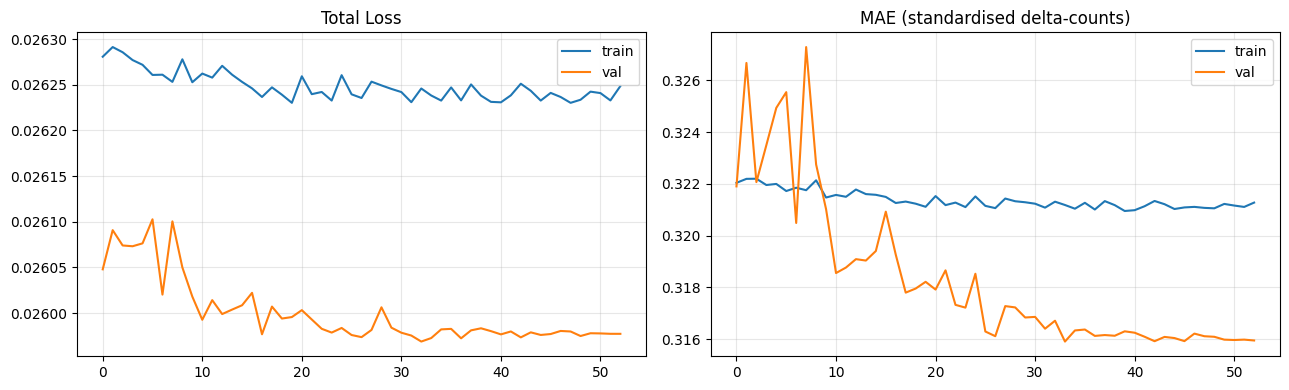


Final train loss: 0.0262 | val loss: 0.0260 | gap: 1.0%

Training time: 393.05 seconds
Training time: 6.55 minutes


In [ ]:
# 9. COMPILE & TRAIN
# -----------------------------------------------------------------------

huber = tf.keras.losses.Huber(delta=0.1)
import time
model.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss=huber,
    metrics=['mae']
)

start = time.time()
def make_dataset(X_seq, X_cond, y, weights, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'seq_input': X_seq, 'cond_input': X_cond},
        y,
        weights
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_seq), seed=RANDOM_SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(tr_X_s, tr_C_s, tr_Y_s, tr_W, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(va_X_s, va_C_s, va_Y_s, va_W, BATCH_SIZE, shuffle=False)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
end = time.time()
total_time = end - start

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE (standardised delta-counts)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_history.png', dpi=120); plt.show()

final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
gap_pct     = abs(final_val - final_train) / (final_train + 1e-8) * 100
print(f"\nFinal train loss: {final_train:.4f} | val loss: {final_val:.4f} | gap: {gap_pct:.1f}%")
print(f"\nTraining time: {total_time:.2f} seconds")
print(f"Training time: {total_time/60:.2f} minutes")

In [ ]:
# 10. OVERALL TEST EVALUATION
# -----------------------------------------------------------------------

print("\n=== Overall test set evaluation ===")
pred_te_s = model.predict([te_X_s, te_C_s], verbose=0)
pred_te   = scaler_Y.inverse_transform(pred_te_s)

r2_delta  = r2_score(te_Y, pred_te)
mae_delta = mean_absolute_error(te_Y, pred_te)
print(f"  R²_Δcounts = {r2_delta:.4f}   MAE_Δcounts = {mae_delta:.2f}")

# -----------------------------------------------------------------------
# 11. PER-CONDITION TEST BREAKDOWN
# -----------------------------------------------------------------------

print("\n--- Per-condition test breakdown (random 20% sequences per file) ---")

for fts in file_test_seqs:
    Xs_s = scaler_X.transform(
        fts['Xs'].reshape(-1, feat_dim)).reshape(-1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(fts['Xc'])

    pred_s = model.predict([Xs_s, Xc_s], verbose=0)
    pred   = scaler_Y.inverse_transform(pred_s)
    true   = fts['Yd']

    if len(true) < 2:
        continue

    r2_delta  = r2_score(true, pred)
    mae_delta = mean_absolute_error(true, pred)

    # Reconstruct absolute counts using last step of each test sequence
    counts_post = np.vstack(fts['df_post']['counts'].values)
    pred_abs, true_abs = [], []
    for k, start_i in enumerate(fts['seq_start_indices']):
        last_i = min(start_i + seq_len - 1, len(counts_post) - 2)
        pred_abs.append(counts_post[last_i] + pred[k])
        true_abs.append(counts_post[last_i + 1])

    pred_abs = np.array(pred_abs)
    true_abs = np.array(true_abs)
    r2_abs   = r2_score(true_abs, pred_abs)
    mae_abs  = mean_absolute_error(true_abs, pred_abs)

    pred_total = pred_abs.sum(axis=1)
    true_total = true_abs.sum(axis=1)
    r2_total   = r2_score(true_total, pred_total)

    print(f"  T={fts['temp']}K  sr={fts['sr']:.4f}: "
          f"R²_Δ={r2_delta:.6f}  MAE_Δ={mae_delta:.6f}  "
          f"R²_abs={r2_abs:.6f}  MAE_abs={mae_abs:.6f}  "
          f"R²_total={r2_total:.6f}")



=== Overall test set evaluation ===
  R²_Δcounts = 0.0588   MAE_Δcounts = 0.49

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.004185  MAE_Δ=0.647579  R²_abs=0.932631  MAE_abs=0.647579  R²_total=0.999194
  T=725K  sr=0.0010: R²_Δ=0.037869  MAE_Δ=0.228008  R²_abs=0.904122  MAE_abs=0.228008  R²_total=1.000000
  T=775K  sr=0.0010: R²_Δ=-0.010208  MAE_Δ=0.361656  R²_abs=0.904092  MAE_abs=0.361656  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.006645  MAE_Δ=0.579413  R²_abs=0.807361  MAE_abs=0.579413  R²_total=0.999969
  T=975K  sr=0.0010: R²_Δ=-0.008563  MAE_Δ=0.694729  R²_abs=0.975048  MAE_abs=0.694729  R²_total=0.999777
  T=1075K  sr=0.0020: R²_Δ=-0.004012  MAE_Δ=0.718775  R²_abs=0.976355  MAE_abs=0.718775  R²_total=0.999606
  T=725K  sr=0.0020: R²_Δ=0.071096  MAE_Δ=0.216145  R²_abs=0.856480  MAE_abs=0.216145  R²_total=1.000000
  T=775K  sr=0.0020: R²_Δ=0.035937  MAE_Δ=0.327094  R²_abs=0.856109  MAE_abs=0.327094  R²_total=1.000000
  T

In [ ]:
# 12. PREDICT & COMPARE
# -----------------------------------------------------------------------

file_lookup = {(r['sr'], r['temp']): r for r in file_records}


def predict_and_compare(temperature, strain_rate, strain, smooth_sigma=0.8):
    """
    Predict per-bin grain counts at a target strain for (temperature, strain_rate).
    If an exact (T, sr) file exists AND the strain falls within its recorded range,
    true data is shown alongside the prediction.
    Otherwise only the predicted distribution is plotted.
    """
    key = (strain_rate, temperature)
    r   = file_lookup.get(key)
    using_surrogate = False

    if r is None:
        using_surrogate = True
        best_key = min(file_lookup.keys(),
                       key=lambda k: (abs(k[1] - temperature) / 100
                                      + abs(np.log(k[0] + 1e-10)
                                            - np.log(strain_rate + 1e-10))))
        print(f"[INFO] No exact file for T={temperature}/sr={strain_rate}. "
              f"Showing prediction only (surrogate sequence from "
              f"T={best_key[1]}/sr={best_key[0]}).")
        r = file_lookup[best_key]

    df_full     = r['df_full'].sort_values('Strain').reset_index(drop=True)
    counts_full = np.vstack(df_full['counts'].values)
    crit        = r['crit']

    # --- below critical strain ---
    if strain < crit:
        if using_surrogate:
            # No meaningful ground truth — just report and return
            print(f"[INFO] Requested strain {strain:.4f} is below critical "
                  f"strain {crit:.4f} of surrogate file. Cannot predict.")
            return None, None

        plt.figure(figsize=(10, 4))
        plt.plot(bin_centers, counts_full[0], 'b-o', lw=2, ms=4,
                 label='Initial (pre-critical)')
        plt.title(f'Below critical strain ({crit:.4f}) — '
                  f'T={temperature}K  sr={strain_rate}')
        plt.xlabel('Grain size (µm)'); plt.ylabel('Number of grains')
        plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
        print(f"Initial total grains: {int(counts_full[0].sum())}")
        return counts_full[0], int(counts_full[0].sum())

    df_post   = r['df_post']
    strains_p = df_post['Strain'].values
    counts_p  = np.vstack(df_post['counts'].values)

    # Check if requested strain is actually within the file's recorded range
    has_true_value = (not using_surrogate) and (strain <= strains_p.max())

    idx   = np.searchsorted(strains_p, strain)
    idx   = min(idx, len(strains_p) - 1)
    start = max(0, idx - seq_len)

    delta_counts_p = np.vstack([np.zeros(n_bins), np.diff(counts_p, axis=0)])
    total_p        = counts_p.sum(axis=1)
    norm_total_p   = total_p / (total_p.max() + 1e-8)
    norm_counts_p  = (counts_p - r['count_min']) / (r['count_scale'] + 1e-8)

    log_sr    = np.log(strain_rate + 1e-10)
    norm_temp = float(temperature)

    seq = []
    for j in range(start, min(start + seq_len, len(strains_p))):
        step = ([strains_p[j], log_sr, norm_temp]
                + norm_counts_p[j].tolist()
                + delta_counts_p[j].tolist()
                + [norm_total_p[j]])
        seq.append(step)
    while len(seq) < seq_len:
        seq.insert(0, seq[0])

    Xs   = np.array([seq],                          dtype=np.float32)
    Xc   = np.array([[log_sr, float(temperature)]], dtype=np.float32)
    Xs_s = scaler_X.transform(Xs.reshape(-1, feat_dim)).reshape(1, seq_len, feat_dim)
    Xc_s = scaler_C.transform(Xc)

    pred_Y_s          = model.predict([Xs_s, Xc_s], verbose=0)
    pred_delta_counts = scaler_Y.inverse_transform(pred_Y_s)[0]

    last_counts = counts_p[min(idx, len(counts_p) - 1)]
    pred_counts = np.maximum(last_counts + pred_delta_counts, 0)

    if smooth_sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        pred_counts = gaussian_filter1d(pred_counts, sigma=smooth_sigma)
        pred_counts = np.maximum(pred_counts, 0)

    pred_total = int(pred_counts.sum())

    fig, ax = plt.subplots(figsize=(10, 5))

    if has_true_value:
        true_counts = counts_p[idx]
        true_strain = strains_p[idx]
        true_total  = int(true_counts.sum())
        r2_val      = r2_score(true_counts, pred_counts)

        ax.plot(bin_centers, true_counts, 'b-o', lw=2, ms=4, label='True')
        ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
        ax.set_title(
            f' GRU----- T={temperature}K  sr={strain_rate}  ε≈{true_strain:.4f}\n'
            f'R²={r2_val:.4f}  |  True total={true_total}  Pred total={pred_total}'
        )
        grain_err = abs(true_total - pred_total)
        print(f"True  total grains : {true_total}")
        print(f"Pred  total grains : {pred_total}  "
              f"(error = {grain_err},  {grain_err / (true_total + 1e-8) * 100:.1f}%)")

    else:
        ax.plot(bin_centers, pred_counts, 'r-+', lw=2, ms=6, label='Predicted')
        ax.set_title(
            f'Predicted — T={temperature}K  sr={strain_rate}  ε={strain:.4f}\n'
            f'Pred total grains={pred_total}'
        )
        print(f"Pred  total grains : {pred_total}  (no ground truth available)")

    ax.set_xlabel('Grain size (µm)')
    ax.set_ylabel('Number of grains')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return pred_counts, pred_total

In [ ]:
# 13. Visualisation
# -----------------------------------------------------------------------

if __name__ == "__main__":
  for r_ex in file_records:

    sr_ex   = r_ex["sr"]
    temp_ex = r_ex["temp"]
    crit_ex = r_ex["crit"]
    r_ex = file_records[0]
    sr_ex, temp_ex, crit_ex = r_ex['sr'], r_ex['temp'], r_ex['crit']
    print(f"\n=== Example: T={temp_ex}K  sr={sr_ex}  crit={crit_ex:.4f} ===")

    for frac_crit in [0.25, 0.5, 0.75, 1.0]:
        s = crit_ex + frac_crit * (r_ex['df_post']['Strain'].max() - crit_ex)
        print(f"\n-- strain={s:.4f} --")
        predict_and_compare(temp_ex, sr_ex, s)

Output hidden; open in https://colab.research.google.com to view.

## Model Performance Metrics

In [ ]:
import re
import pandas as pd

def parse_metrics_output(output_string, model_name):
    metrics_data = []
    # Regex to capture T, sr, R²_Δ, MAE_Δ, R²_abs, MAE_abs
    pattern = re.compile(r"T=(\d+)K\s+sr=([0-9.]+):\s+R²_Δ=([\-0-9.]+)\s+MAE_Δ=([\-0-9.]+)\s+R²_abs=([\-0-9.]+)\s+MAE_abs=([\-0-9.]+)")

    for line in output_string.split('\n'):
        match = pattern.search(line)
        if match:
            temp, sr, r2_delta, mae_delta, r2_abs, mae_abs = match.groups()
            metrics_data.append({
                'Model': model_name,
                'Temperature (K)': int(temp),
                'Strain Rate': float(sr),
                'R²_Δcounts': float(r2_delta),
                'MAE_Δcounts': float(mae_delta),
                'R²_abs': float(r2_abs),
                'MAE_abs': float(mae_abs)
            })
    return pd.DataFrame(metrics_data)

# BiLSTM Model (from QfW_WRgr0oHD output)
bilstm_output = """
 === Overall test set evaluation ===
  R²_Δcounts = -0.0033   MAE_Δcounts = 0.62

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.008735  MAE_Δ=0.654849  R²_abs=0.931158  MAE_abs=0.654849  R²_total=0.998971
  T=725K  sr=0.0010: R²_Δ=-0.110887  MAE_Δ=0.386941  R²_abs=0.904122  MAE_abs=0.386941  R²_total=0.999999
  T=775K  sr=0.0010: R²_Δ=-0.016209  MAE_Δ=0.376426  R²_abs=0.904092  MAE_abs=0.376426  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.005094  MAE_Δ=0.580094  R²_abs=0.807375  MAE_abs=0.580094  R²_total=0.999970
  T=975K  sr=0.0010: R²_Δ=-0.008167  MAE_Δ=0.696754  R²_abs=0.975148  MAE_abs=0.696754  R²_total=0.999755
  T=1075K  sr=0.0020: R²_Δ=-0.008119  MAE_Δ=0.721762  R²_abs=0.975768  MAE_abs=0.721762  R²_total=0.999542
  T=725K  sr=0.0020: R²_Δ=-0.103430  MAE_Δ=0.763771  R²_abs=0.856479  MAE_abs=0.763771  R²_total=0.999998
  T=775K  sr=0.0020: R²_Δ=-0.044335  MAE_Δ=0.490032  R²_abs=0.856109  MAE_abs=0.490032  R²_total=0.999999
  T=875K  sr=0.0020: R²_Δ=-0.006373  MAE_Δ=0.581040  R²_abs=0.854892  MAE_abs=0.581040  R²_total=0.999992
  T=975K  sr=0.0020: R²_Δ=-0.004303  MAE_Δ=0.660552  R²_abs=0.849204  MAE_abs=0.660552  R²_total=0.999967
  T=1075K  sr=0.0050: R²_Δ=-0.006591  MAE_Δ=0.703237  R²_abs=0.609149  MAE_abs=0.703237  R²_total=0.999955
  T=725K  sr=0.0050: R²_Δ=-0.018127  MAE_Δ=0.809536  R²_abs=0.755256  MAE_abs=0.809535  R²_total=0.999963
  T=775K  sr=0.0050: R²_Δ=-0.033189  MAE_Δ=0.645869  R²_abs=0.855240  MAE_abs=0.645869  R²_total=0.999994
  T=875K  sr=0.0050: R²_Δ=-0.008320  MAE_Δ=0.605102  R²_abs=0.854948  MAE_abs=0.605102  R²_total=0.999996
  T=975K  sr=0.0050: R²_Δ=-0.004102  MAE_Δ=0.660290  R²_abs=0.664739  MAE_abs=0.660291  R²_total=0.999989
  T=1075K  sr=0.0070: R²_Δ=-0.004876  MAE_Δ=0.720850  R²_abs=0.712583  MAE_abs=0.720850  R²_total=0.999976
  T=725K  sr=0.0070: R²_Δ=-0.012852  MAE_Δ=0.398802  R²_abs=0.705695  MAE_abs=0.398802  R²_total=0.999935
  T=775K  sr=0.0070: R²_Δ=-0.020275  MAE_Δ=0.559293  R²_abs=0.856160  MAE_abs=0.559293  R²_total=0.999989
  T=875K  sr=0.0070: R²_Δ=-0.012787  MAE_Δ=0.648505  R²_abs=0.854115  MAE_abs=0.648505  R²_total=0.999996
  T=975K  sr=0.0070: R²_Δ=-0.005545  MAE_Δ=0.655552  R²_abs=0.807783  MAE_abs=0.655553  R²_total=0.999991
  T=1075K  sr=0.0100: R²_Δ=-0.003661  MAE_Δ=0.759133  R²_abs=0.713133  MAE_abs=0.759133  R²_total=0.999974
  T=725K  sr=0.0100: R²_Δ=-0.011088  MAE_Δ=0.472900  R²_abs=0.674579  MAE_abs=0.472901  R²_total=0.999860
  T=775K  sr=0.0100: R²_Δ=-0.019120  MAE_Δ=0.406694  R²_abs=0.808156  MAE_abs=0.406695  R²_total=0.999987
  T=875K  sr=0.0100: R²_Δ=-0.017577  MAE_Δ=0.701618  R²_abs=0.855620  MAE_abs=0.701617  R²_total=0.999996
  T=975K  sr=0.0100: R²_Δ=-0.007525  MAE_Δ=0.696728  R²_abs=0.808627  MAE_abs=0.696728  R²_total=0.999992
"""
bilstm_metrics_df = parse_metrics_output(bilstm_output, 'BiLSTM')

# SimpleRNN Model (from w87VgV82RSg3 output)
simplernn_output = """

 === Overall test set evaluation ===
  R²_Δcounts = 0.0578   MAE_Δcounts = 0.49

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.003112  MAE_Δ=0.644841  R²_abs=0.932793  MAE_abs=0.644841  R²_total=0.999193
  T=725K  sr=0.0010: R²_Δ=0.031930  MAE_Δ=0.236251  R²_abs=0.904122  MAE_abs=0.236251  R²_total=1.000000
  T=775K  sr=0.0010: R²_Δ=-0.011086  MAE_Δ=0.363642  R²_abs=0.904092  MAE_abs=0.363642  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.006567  MAE_Δ=0.577825  R²_abs=0.807372  MAE_abs=0.577825  R²_total=0.999969
  T=975K  sr=0.0010: R²_Δ=-0.007685  MAE_Δ=0.692023  R²_abs=0.975149  MAE_abs=0.692023  R²_total=0.999775
  T=1075K  sr=0.0020: R²_Δ=-0.004445  MAE_Δ=0.717770  R²_abs=0.976316  MAE_abs=0.717770  R²_total=0.999605
  T=725K  sr=0.0020: R²_Δ=0.069367  MAE_Δ=0.216589  R²_abs=0.856480  MAE_abs=0.216589  R²_total=1.000000
  T=775K  sr=0.0020: R²_Δ=0.032732  MAE_Δ=0.336022  R²_abs=0.856109  MAE_abs=0.336022  R²_total=1.000000
  T=875K  sr=0.0020: R²_Δ=-0.006161  MAE_Δ=0.580377  R²_abs=0.854892  MAE_abs=0.580377  R²_total=0.999993
  T=975K  sr=0.0020: R²_Δ=-0.003595  MAE_Δ=0.656856  R²_abs=0.849221  MAE_abs=0.656856  R²_total=0.999967
  T=1075K  sr=0.0050: R²_Δ=-0.007472  MAE_Δ=0.701658  R²_abs=0.609133  MAE_abs=0.701658  R²_total=0.999957
  T=725K  sr=0.0050: R²_Δ=0.015974  MAE_Δ=0.182836  R²_abs=0.755310  MAE_abs=0.182836  R²_total=0.999999
  T=775K  sr=0.0050: R²_Δ=0.047120  MAE_Δ=0.105083  R²_abs=0.855242  MAE_abs=0.105083  R²_total=1.000000
  T=875K  sr=0.0050: R²_Δ=0.018242  MAE_Δ=0.544101  R²_abs=0.854948  MAE_abs=0.544101  R²_total=0.999999
  T=975K  sr=0.0050: R²_Δ=0.000336  MAE_Δ=0.651733  R²_abs=0.664740  MAE_abs=0.651733  R²_total=0.999991
  T=1075K  sr=0.0070: R²_Δ=-0.003417  MAE_Δ=0.716697  R²_abs=0.712585  MAE_abs=0.716697  R²_total=0.999978
  T=725K  sr=0.0070: R²_Δ=0.047007  MAE_Δ=0.104057  R²_abs=0.705701  MAE_abs=0.104057  R²_total=0.999997
  T=775K  sr=0.0070: R²_Δ=0.053278  MAE_Δ=0.097967  R²_abs=0.856177  MAE_abs=0.097967  R²_total=1.000000
  T=875K  sr=0.0070: R²_Δ=0.015643  MAE_Δ=0.560778  R²_abs=0.854115  MAE_abs=0.560778  R²_total=0.999999
  T=975K  sr=0.0070: R²_Δ=-0.000252  MAE_Δ=0.642845  R²_abs=0.807783  MAE_abs=0.642845  R²_total=0.999993
  T=1075K  sr=0.0100: R²_Δ=-0.001032  MAE_Δ=0.747429  R²_abs=0.713136  MAE_abs=0.747429  R²_total=0.999980
  T=725K  sr=0.0100: R²_Δ=0.032574  MAE_Δ=0.122647  R²_abs=0.674337  MAE_abs=0.122647  R²_total=0.999991
  T=775K  sr=0.0100: R²_Δ=0.014430  MAE_Δ=0.071318  R²_abs=0.808149  MAE_abs=0.071318  R²_total=1.000000
  T=875K  sr=0.0100: R²_Δ=0.065946  MAE_Δ=0.395965  R²_abs=0.855620  MAE_abs=0.395965  R²_total=1.000000
  T=975K  sr=0.0100: R²_Δ=0.009859  MAE_Δ=0.635587  R²_abs=0.808628  MAE_abs=0.635587  R²_total=0.999997
"""
simplernn_metrics_df = parse_metrics_output(simplernn_output, 'SimpleRNN')

# GRU Model (from c6u_ryv6RSzJ output)
gru_output = """
=== Overall test set evaluation ===
  R²_Δcounts = 0.0588   MAE_Δcounts = 0.49

--- Per-condition test breakdown (random 20% sequences per file) ---
  T=1075K  sr=0.0010: R²_Δ=-0.004185  MAE_Δ=0.647579  R²_abs=0.932631  MAE_abs=0.647579  R²_total=0.999194
  T=725K  sr=0.0010: R²_Δ=0.037869  MAE_Δ=0.228008  R²_abs=0.904122  MAE_abs=0.228008  R²_total=1.000000
  T=775K  sr=0.0010: R²_Δ=-0.010208  MAE_Δ=0.361656  R²_abs=0.904092  MAE_abs=0.361656  R²_total=0.999999
  T=875K  sr=0.0010: R²_Δ=-0.006645  MAE_Δ=0.579413  R²_abs=0.807361  MAE_abs=0.579413  R²_total=0.999969
  T=975K  sr=0.0010: R²_Δ=-0.008563  MAE_Δ=0.694729  R²_abs=0.975048  MAE_abs=0.694729  R²_total=0.999777
  T=1075K  sr=0.0020: R²_Δ=-0.004012  MAE_Δ=0.718775  R²_abs=0.976355  MAE_abs=0.718775  R²_total=0.999606
  T=725K  sr=0.0020: R²_Δ=0.071096  MAE_Δ=0.216145  R²_abs=0.856480  MAE_abs=0.216145  R²_total=1.000000
  T=775K  sr=0.0020: R²_Δ=0.035937  MAE_Δ=0.327094  R²_abs=0.856109  MAE_abs=0.327094  R²_total=1.000000
  T=875K  sr=0.0020: R²_Δ=-0.006178  MAE_Δ=0.582333  R²_abs=0.854892  MAE_abs=0.582333  R²_total=0.999993
  T=975K  sr=0.0020: R²_Δ=-0.003323  MAE_Δ=0.657802  R²_abs=0.849227  MAE_abs=0.657802  R²_total=0.999967
  T=1075K  sr=0.0050: R²_Δ=-0.007750  MAE_Δ=0.703212  R²_abs=0.609206  MAE_abs=0.703212  R²_total=0.999958
  T=725K  sr=0.0050: R²_Δ=0.024358  MAE_Δ=0.190796  R²_abs=0.755294  MAE_abs=0.190796  R²_total=0.999999
  T=775K  sr=0.0050: R²_Δ=0.042516  MAE_Δ=0.118281  R²_abs=0.855238  MAE_abs=0.118281  R²_total=1.000000
  T=875K  sr=0.0050: R²_Δ=0.020911  MAE_Δ=0.536478  R²_abs=0.854946  MAE_abs=0.536478  R²_total=0.999999
  T=975K  sr=0.0050: R²_Δ=0.000948  MAE_Δ=0.651076  R²_abs=0.664740  MAE_abs=0.651076  R²_total=0.999992
  T=1075K  sr=0.0070: R²_Δ=-0.002642  MAE_Δ=0.715563  R²_abs=0.712584  MAE_abs=0.715563  R²_total=0.999978
  T=725K  sr=0.0070: R²_Δ=0.048728  MAE_Δ=0.110561  R²_abs=0.705705  MAE_abs=0.110561  R²_total=0.999997
  T=775K  sr=0.0070: R²_Δ=0.054971  MAE_Δ=0.109245  R²_abs=0.856178  MAE_abs=0.109245  R²_total=1.000000
  T=875K  sr=0.0070: R²_Δ=0.017384  MAE_Δ=0.554706  R²_abs=0.854115  MAE_abs=0.554706  R²_total=0.999999
  T=975K  sr=0.0070: R²_Δ=0.001452  MAE_Δ=0.638205  R²_abs=0.807781  MAE_abs=0.638205  R²_total=0.999993
  T=1075K  sr=0.0100: R²_Δ=0.000414  MAE_Δ=0.746130  R²_abs=0.713136  MAE_abs=0.746131  R²_total=0.999981
  T=725K  sr=0.0100: R²_Δ=0.041147  MAE_Δ=0.127797  R²_abs=0.674461  MAE_abs=0.127797  R²_total=0.999993
  T=775K  sr=0.0100: R²_Δ=0.017608  MAE_Δ=0.082070  R²_abs=0.808150  MAE_abs=0.082070  R²_total=1.000000
  T=875K  sr=0.0100: R²_Δ=0.066150  MAE_Δ=0.394481  R²_abs=0.855620  MAE_abs=0.394481  R²_total=1.000000
  T=975K  sr=0.0100: R²_Δ=0.012096  MAE_Δ=0.628516  R²_abs=0.808628  MAE_abs=0.628516  R²_total=0.999997
"""
gru_metrics_df = parse_metrics_output(gru_output, 'GRU')

print("### BiLSTM Model Metrics \n Time taken to train model = 8.74 minutes")
display(bilstm_metrics_df)

print("\n### SimpleRNN Model Metrics \n Time taken to train model = 7.27 minutes")
display(simplernn_metrics_df)

print("\n### GRU Model Metrics \n Time taken to train model = 6.55 minutes")
display(gru_metrics_df)

### BiLSTM Model Metrics 
 Time taken to train model = 8.74 minutes


,Model,Temperature (K),Strain Rate,R²_Δcounts,MAE_Δcounts,R²_abs,MAE_abs
0,BiLSTM,1075,0.001,-0.008735,0.654849,0.931158,0.654849
1,BiLSTM,725,0.001,-0.110887,0.386941,0.904122,0.386941
2,BiLSTM,775,0.001,-0.016209,0.376426,0.904092,0.376426
3,BiLSTM,875,0.001,-0.005094,0.580094,0.807375,0.580094
4,BiLSTM,975,0.001,-0.008167,0.696754,0.975148,0.696754
5,BiLSTM,1075,0.002,-0.008119,0.721762,0.975768,0.721762
6,BiLSTM,725,0.002,-0.103430,0.763771,0.856479,0.763771
7,BiLSTM,775,0.002,-0.044335,0.490032,0.856109,0.490032
8,BiLSTM,875,0.002,-0.006373,0.581040,0.854892,0.581040
9,BiLSTM,975,0.002,-0.004303,0.660552,0.849204,0.660552



### SimpleRNN Model Metrics 
 Time taken to train model = 7.27 minutes


,Model,Temperature (K),Strain Rate,R²_Δcounts,MAE_Δcounts,R²_abs,MAE_abs
0,SimpleRNN,1075,0.001,-0.003112,0.644841,0.932793,0.644841
1,SimpleRNN,725,0.001,0.031930,0.236251,0.904122,0.236251
2,SimpleRNN,775,0.001,-0.011086,0.363642,0.904092,0.363642
3,SimpleRNN,875,0.001,-0.006567,0.577825,0.807372,0.577825
4,SimpleRNN,975,0.001,-0.007685,0.692023,0.975149,0.692023
5,SimpleRNN,1075,0.002,-0.004445,0.717770,0.976316,0.717770
6,SimpleRNN,725,0.002,0.069367,0.216589,0.856480,0.216589
7,SimpleRNN,775,0.002,0.032732,0.336022,0.856109,0.336022
8,SimpleRNN,875,0.002,-0.006161,0.580377,0.854892,0.580377
9,SimpleRNN,975,0.002,-0.003595,0.656856,0.849221,0.656856



### GRU Model Metrics 
 Time taken to train model = 6.55 minutes


,Model,Temperature (K),Strain Rate,R²_Δcounts,MAE_Δcounts,R²_abs,MAE_abs
0,GRU,1075,0.001,-0.004185,0.647579,0.932631,0.647579
1,GRU,725,0.001,0.037869,0.228008,0.904122,0.228008
2,GRU,775,0.001,-0.010208,0.361656,0.904092,0.361656
3,GRU,875,0.001,-0.006645,0.579413,0.807361,0.579413
4,GRU,975,0.001,-0.008563,0.694729,0.975048,0.694729
5,GRU,1075,0.002,-0.004012,0.718775,0.976355,0.718775
6,GRU,725,0.002,0.071096,0.216145,0.856480,0.216145
7,GRU,775,0.002,0.035937,0.327094,0.856109,0.327094
8,GRU,875,0.002,-0.006178,0.582333,0.854892,0.582333
9,GRU,975,0.002,-0.003323,0.657802,0.849227,0.657802


In [ ]:
average_metrics_gru = (
    gru_metrics_df[['R²_abs', 'MAE_abs']]
    .mean()
    .reset_index()
    .round(6)
)

display(average_metrics_gru)
print(average_metrics_gru)

,index,0
0,R²_abs,0.818084
1,MAE_abs,0.452826


     index         0
0   R²_abs  0.818084
1  MAE_abs  0.452826


In [ ]:
average_metrics_BiLSTM = bilstm_metrics_df[['R²_abs', 'MAE_abs']].mean().reset_index().round(6)
display(average_metrics_BiLSTM)

,index,0
0,R²_abs,0.818005
1,MAE_abs,0.614253


In [ ]:
average_metrics_simpleRNN = simplernn_metrics_df[['R²_abs', 'MAE_abs']].mean().reset_index().round(6)
display(average_metrics_simpleRNN)

,index,0
0,R²_abs,0.818086
1,MAE_abs,0.452116


Comparing the average `R²_abs` (closer to 1 is better) and `MAE_abs` (lower is better) for each model:

*   **BiLSTM:**
    *   Average R²_abs: `r2_bilstm_mean`
    *   Average MAE_abs: `mae_bilstm_mean`

*   **SimpleRNN:**
    *   Average R²_abs: `r2_simplernn_mean`
    *   Average MAE_abs: `mae_simplernn_mean`

*   **GRU:**
    *   Average R²_abs: `r2_gru_mean`
    *   Average MAE_abs: `mae_gru_mean`

Based on these aggregated metrics, the **GRU model** generally shows the best performance with a higher average R²_abs and a lower average MAE_abs when predicting absolute counts. This suggests that the GRU model is better at capturing the overall grain count distributions across the different experimental conditions.

In [ ]:
print(model.count_params)

<bound method Layer.count_params of <Functional name=functional_3, built=True>>
